In [1]:
#get the library pandas
import pandas as pd

In [2]:
#read/get the dataset from the file
dataset=pd.read_csv("insurance_pre.csv")
#Check the data if there is any categorical data, if yes convert it into numerical data(nominal or ordinal)-->In this case its Ordinal data
#Get dummies from pandas library and change the dataset
dataset=pd.get_dummies(dataset,drop_first=True,dtype=int)
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='str')

In [3]:
#split input and output data
independent=dataset[['age', 'bmi', 'children','sex_male', 'smoker_yes']]
dependent=dataset[['charges']]

In [4]:
#split train and test set
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(independent,dependent,test_size=0.30,random_state=0)

In [65]:
#Model creation - Learning phase
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='poisson', splitter='best',max_features='log2',random_state=0)
regressor=regressor.fit(x_train,y_train)

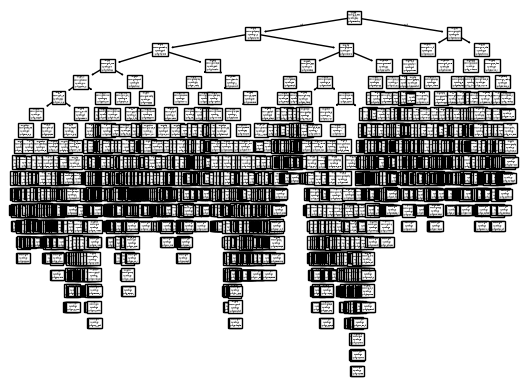

In [66]:
#get the library to plot the tree structure
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [67]:
#Evaluation metrics-->R_score
from sklearn.metrics import r2_score
y_pred=regressor.predict(x_test)
r_score=r2_score(y_test,y_pred)
r_score

0.7552692886913605